# Fish image classifier (transfer learning)

**Dataset:** `data/FishImgDataset/{train,val,test}` (ImageFolder layout).

**Outputs:** `fish-classifier/models/fish_model.pt`, `class_names.json`, `training_config.json` (artifacts are gitignored).

Run cells in order. Set `EPOCHS_HEAD = 1` and `EPOCHS_FT = 0` for a quick smoke run.

In [1]:
from __future__ import annotations

import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm


def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / "data" / "FishImgDataset" / "train").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find data/FishImgDataset/train. Open the notebook from the repo or set cwd to repo root."
    )


REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data" / "FishImgDataset"
MODELS_DIR = REPO_ROOT / "fish-classifier" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

assert (DATA_DIR / "train").is_dir(), f"Missing train: {DATA_DIR / 'train'}"
assert (DATA_DIR / "val").is_dir(), f"Missing val: {DATA_DIR / 'val'}"
assert (DATA_DIR / "test").is_dir(), f"Missing test: {DATA_DIR / 'test'}"

print("REPO_ROOT =", REPO_ROOT)
print("DATA_DIR  =", DATA_DIR)
print("MODELS_DIR=", MODELS_DIR)


REPO_ROOT = /Users/brandonnguyen/Projects/seattle-sonics-whale-tracker
DATA_DIR  = /Users/brandonnguyen/Projects/seattle-sonics-whale-tracker/data/FishImgDataset
MODELS_DIR= /Users/brandonnguyen/Projects/seattle-sonics-whale-tracker/fish-classifier/models


In [2]:
IMG_SIZE = 224
BATCH = 32
EPOCHS_HEAD = 5
EPOCHS_FT = 3
LR_HEAD = 1e-3
LR_FT = 1e-4
SEED = 42
BACKBONE = "mobilenet_v3_small"
DO_FINETUNE = True

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
else:
    device = torch.device("cpu")

USE_CUDA = device.type == "cuda"
USE_MPS = device.type == "mps"
PIN_MEMORY = USE_CUDA
NUM_WORKERS = 0 if USE_MPS else (2 if device.type == "cpu" else 4)
PERSISTENT_WORKERS = NUM_WORKERS > 0

print(f"device={device} num_workers={NUM_WORKERS} pin_memory={PIN_MEMORY}")


device=mps num_workers=0 pin_memory=False


In [4]:
train_tf = transforms.Compose(
    [
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)
eval_tf = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_tf)
val_ds = datasets.ImageFolder(DATA_DIR / "val", transform=eval_tf)
test_ds = datasets.ImageFolder(DATA_DIR / "test", transform=eval_tf)

assert train_ds.classes == val_ds.classes == test_ds.classes, "Class mismatch across splits"
NUM_CLASSES = len(train_ds.classes)
print("NUM_CLASSES =", NUM_CLASSES)
print("Train / val / test sizes:", len(train_ds), len(val_ds), len(test_ds))

dl_kw = dict(
    batch_size=BATCH,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)
if NUM_WORKERS == 0:
    dl_kw.pop("persistent_workers", None)

train_loader = DataLoader(train_ds, shuffle=True, **dl_kw)
val_loader = DataLoader(val_ds, shuffle=False, **dl_kw)
test_loader = DataLoader(test_ds, shuffle=False, **dl_kw)

from collections import Counter

c_train = Counter([train_ds.targets[i] for i in range(len(train_ds))])
print("Per-class train counts (first 5):", list(c_train.items())[:5])


NUM_CLASSES = 31
Train / val / test sizes: 8793 2751 1760
Per-class train counts (first 5): [(0, 171), (1, 201), (2, 200), (3, 314), (4, 152)]


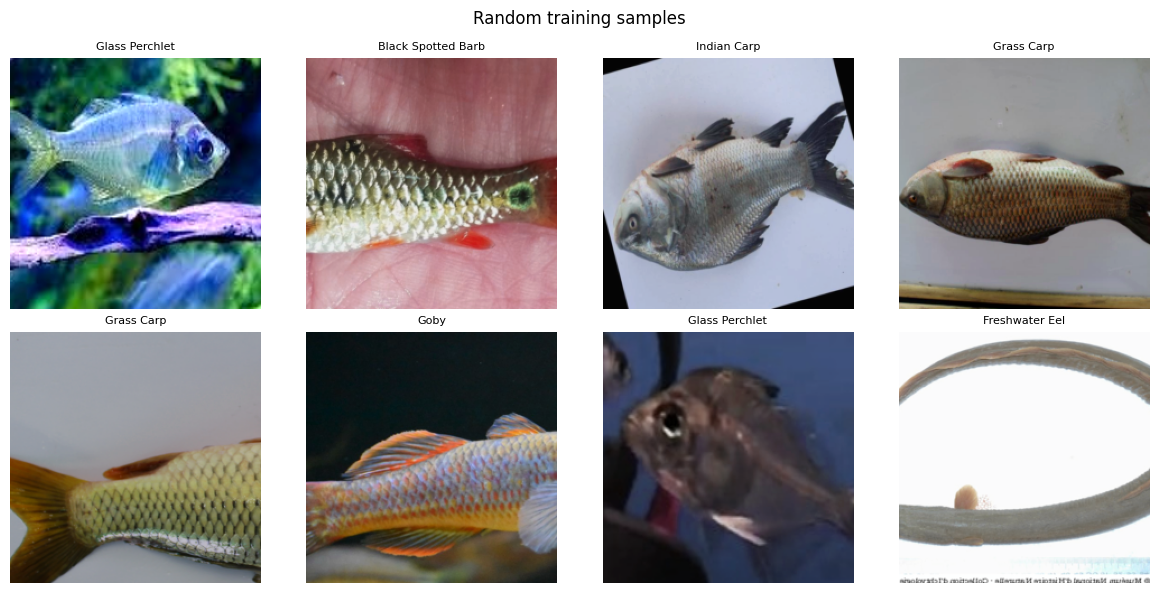

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()
idxs = random.sample(range(len(train_ds)), min(8, len(train_ds)))
for ax, i in zip(axes, idxs):
    img_tensor, y = train_ds[i]
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(train_ds.classes[y], fontsize=8)
    ax.axis("off")
plt.suptitle("Random training samples")
plt.tight_layout()
plt.show()


In [6]:
def build_model(num_classes: int) -> nn.Module:
    if BACKBONE != "mobilenet_v3_small":
        raise ValueError("Set BACKBONE to mobilenet_v3_small or extend build_model.")
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_features = m.classifier[3].in_features
    m.classifier[3] = nn.Linear(in_features, num_classes)
    return m


model = build_model(NUM_CLASSES).to(device)

for p in model.features.parameters():
    p.requires_grad = False
for p in model.classifier.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /Users/brandonnguyen/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 19.6MB/s]


Trainable params: 622,623 / 1,549,631


In [7]:
def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    pred = logits.argmax(dim=1)
    return (pred == targets).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=USE_CUDA)
        y = y.to(device, non_blocking=USE_CUDA)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits.detach(), y) * bs
        n += bs
    return total_loss / n, total_acc / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for x, y in tqdm(loader, desc="eval", leave=False):
        x = x.to(device, non_blocking=USE_CUDA)
        y = y.to(device, non_blocking=USE_CUDA)
        if USE_CUDA:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)
        else:
            logits = model(x)
            loss = criterion(logits, y)
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs
    return total_loss / n, total_acc / n


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=LR_HEAD, weight_decay=0.01
)
scaler = torch.cuda.amp.GradScaler() if USE_CUDA else None

best_val_acc = -1.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS_HEAD):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS_HEAD}  train_loss={tr_loss:.4f} acc={tr_acc:.4f}  val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        cpu_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        torch.save(cpu_state, MODELS_DIR / "fish_model.pt")
        print(f"  saved best checkpoint (val_acc={best_val_acc:.4f})")

print("Head training done. Best val_acc:", best_val_acc)


train:   0%|          | 0/275 [00:00<?, ?it/s]

eval:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch 1/5  train_loss=1.6371 acc=0.5435  val_loss=0.7774 val_acc=0.7714
  saved best checkpoint (val_acc=0.7714)


train:   0%|          | 0/275 [00:00<?, ?it/s]

eval:   0%|          | 0/86 [00:00<?, ?it/s]

...

eval:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch 4/5  train_loss=0.9732 acc=0.7117  val_loss=0.5164 val_acc=0.8397


train:   0%|          | 0/275 [00:00<?, ?it/s]

eval:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch 5/5  train_loss=0.9283 acc=0.7241  val_loss=0.4627 val_acc=0.8571
  saved best checkpoint (val_acc=0.8571)
Head training done. Best val_acc: 0.8571428571861902


In [8]:
if DO_FINETUNE and EPOCHS_FT > 0:
    for p in model.features[-2].parameters():
        p.requires_grad = True
    for p in model.features[-1].parameters():
        p.requires_grad = True

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=LR_FT, weight_decay=0.01
    )
    scaler = torch.cuda.amp.GradScaler() if USE_CUDA else None

    for epoch in range(EPOCHS_FT):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(f"FT epoch {epoch+1}/{EPOCHS_FT}  train_loss={tr_loss:.4f} acc={tr_acc:.4f}  val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            cpu_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            torch.save(cpu_state, MODELS_DIR / "fish_model.pt")
            print(f"  saved best checkpoint (val_acc={best_val_acc:.4f})")
else:
    print("Skipping fine-tune (DO_FINETUNE=False or EPOCHS_FT=0).")


train:   0%|          | 0/275 [00:00<?, ?it/s]

eval:   0%|          | 0/86 [00:00<?, ?it/s]

FT epoch 1/3  train_loss=0.7551 acc=0.7750  val_loss=0.3350 val_acc=0.9029
  saved best checkpoint (val_acc=0.9029)


train:   0%|          | 0/275 [00:00<?, ?it/s]

eval:   0%|          | 0/86 [00:00<?, ?it/s]

FT epoch 2/3  train_loss=0.7009 acc=0.7939  val_loss=0.3132 val_acc=0.9102
  saved best checkpoint (val_acc=0.9102)


train:   0%|          | 0/275 [00:00<?, ?it/s]

eval:   0%|          | 0/86 [00:00<?, ?it/s]

FT epoch 3/3  train_loss=0.6664 acc=0.8017  val_loss=0.2973 val_acc=0.9157
  saved best checkpoint (val_acc=0.9157)


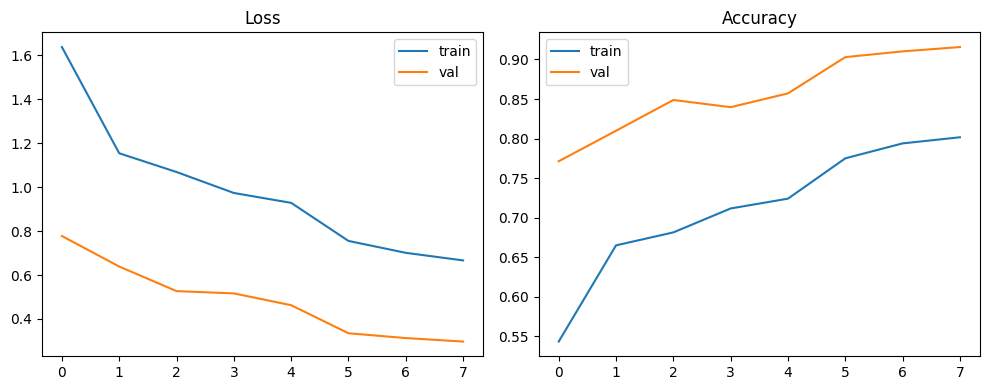

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].legend()
ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy")
ax[1].legend()
plt.tight_layout()
plt.show()


In [10]:
best_state = torch.load(MODELS_DIR / "fish_model.pt", map_location=device)
model.load_state_dict(best_state)
model.to(device)

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test loss={test_loss:.4f}  test_acc={test_acc:.4f}")

all_preds: list[int] = []
all_labels: list[int] = []
model.eval()
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="test collect"):
        x = x.to(device, non_blocking=USE_CUDA)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy().tolist()
        all_preds.extend(pred)
        all_labels.extend(y.numpy().tolist())

print(classification_report(all_labels, all_preds, target_names=test_ds.classes, digits=3))

cm = confusion_matrix(all_labels, all_preds)
wrong = cm.sum(axis=1) - np.diag(cm)
top_mis = np.argsort(-wrong)[:8]
print("Classes with most misclassifications (index, name, wrong count):")
for i in top_mis:
    print(i, test_ds.classes[i], int(wrong[i]))


/var/folders/ss/47jjth2d78jb6twcnpwml51w0000gn/T/ipykernel_97789/45322856.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_state = torch.load(MODELS_DIR / "fish_mode

eval:   0%|          | 0/55 [00:00<?, ?it/s]

Test loss=0.3255  test_acc=0.8966


test collect:   0%|          | 0/55 [00:00<?, ?it/s]

                       precision    recall  f1-score   support

               Bangus      0.743     0.765     0.754        34
        Big Head Carp      0.878     0.837     0.857        43
   Black Spotted Barb      0.914     0.800     0.853        40
              Catfish      0.844     0.871     0.857        62
       Climbing Perch      0.923     0.800     0.857        30
 Fourfinger Threadfin      0.744     0.842     0.790        38
       Freshwater Eel      0.911     0.927     0.919        55
       Glass Perchlet      0.945     0.896     0.920        77
                 Goby      0.829     0.935     0.879       124
            Gold Fish      0.952     0.976     0.964        41
              Gourami      0.968     0.968     0.968        63
           Grass Carp      0.951     0.979     0.965       238
 Green Spotted Puffer      1.000     1.000     1.000        22
          Indian Carp      1.000     0.943     0.971        53
  Indo-Pacific Tarpon      0.821     0.821     0.821  

In [11]:
cfg = {
    "backbone": BACKBONE,
    "img_size": IMG_SIZE,
    "mean": list(IMAGENET_MEAN),
    "std": list(IMAGENET_STD),
    "num_classes": NUM_CLASSES,
    "class_order_note": "Matches torchvision ImageFolder alphabetical class order on train split.",
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
}
(MODELS_DIR / "class_names.json").write_text(json.dumps(train_ds.classes, indent=2))
(MODELS_DIR / "training_config.json").write_text(json.dumps(cfg, indent=2))
print("Wrote class_names.json and training_config.json to", MODELS_DIR)


Wrote class_names.json and training_config.json to /Users/brandonnguyen/Projects/seattle-sonics-whale-tracker/fish-classifier/models


In [13]:
class_names = json.loads((MODELS_DIR / "class_names.json").read_text())
assert len(class_names) == NUM_CLASSES

smoke_model = build_model(NUM_CLASSES)
state = torch.load(MODELS_DIR / "fish_model.pt", map_location=device, weights_only=True)
smoke_model.load_state_dict(state)
smoke_model.to(device).eval()

idx = 0
path, target_idx = test_ds.samples[idx]
img_pil = Image.open(path).convert("RGB")
x = eval_tf(img_pil).unsqueeze(0).to(device, non_blocking=USE_CUDA)
with torch.no_grad():
    logits = smoke_model(x)
pred_idx = int(logits.argmax(dim=1).item())
pred_name = class_names[pred_idx]
true_name = test_ds.classes[target_idx]
print("Smoke test (first test image file):")
print("  path:", path)
print("  true:", true_name)
print("  pred:", pred_name)
print("  match:", pred_name == true_name)


Smoke test (first test image file):
  path: /Users/brandonnguyen/Projects/seattle-sonics-whale-tracker/data/FishImgDataset/test/Bangus/Bangus 103.jpg
  true: Bangus
  pred: Bangus
  match: True
